In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix, classification_report,  roc_curve, precision_recall_curve
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.calibration import calibration_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive"
print(os.listdir(path))

['Colab Notebooks', 'IMG_20240317_212159_311 (1).jpg', 'IMG_20240317_212159_311.jpg', 'Subham_Class_Schedule.pdf', 'Quant books', 'Quant Coding questions.gdoc', 'Python Basics.gdoc', 'GoodNotes', 'Internship list.gdoc', 'Untitled.gdoc', 'Internship test', 'Subham_Khinchi.pdf', 'Khinchi_Subham (1).pdf', 'Hulls problems Midterm.pdf', 'ST 501.gdoc', 'Five Momentum Factors.gdoc', "Merton's Model.gdoc", 'Resume - Subham Khinchi-2.pdf', 'Stout interview.gdoc', 'Khinchi_Subham_resume.pdf', 'khinchi,subham_1.png', 'khinchi,subham_2.png', 'khinchi,subham_3.png', 'khinchi,subham_4.png', 'khinchi,subham_5.png', 'khinchi,subham_6.png', 'Khinchi,Subham (1).docx', 'Khinchi,Subham.docx', 'Khinchi_Subham_SOP.pdf', 'Reference_Zhitian_Deng.pdf', 'Prep.gdoc', 'FIM 500 Project Video', 'Resume- Subham Khinchi (1).pdf', 'Resume- Subham Khinchi.pdf', 'JD.gdoc', 'Project bullet points.gdoc', 'ST 563', 'Untitled document.gdoc', 'PD Model files', 'ST503 Regression', 'ST563 Midterm I.gdoc', 'Meeting Reports', 'K

In [ ]:
file_path = r"/content/drive/MyDrive/final_master_loan_data.csv" #file downloaded
df = pd.read_csv(file_path)
#df= df.drop(["First Payment Date", "Monthly Reporting Period"], axis=1)
df.head()

,Loan_ID,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Remaining Months to Legal Maturity,Defect Settlement Date,Modification Flag,Zero Balance Code,Zero Balance Effective Date,...,Number of Borrowers,Seller Name,Servicer Name,Super Conforming Flag,Pre-HARP Loan Sequence Number,Program Indicator,HARP Indicator,Property Valuation Method,Interest Only (I/O) Indicator,Mortgage Insurance Cancellation Indicator
0,F14Q10000011,201402,62000.0,0,0,180,NaN,NaN,NaN,NaN,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,9,N,9
1,F14Q10000011,201403,62000.0,0,1,179,NaN,NaN,NaN,NaN,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,9,N,9
2,F14Q10000011,201404,62000.0,0,2,178,NaN,NaN,NaN,NaN,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,9,N,9
3,F14Q10000011,201405,61000.0,0,3,177,NaN,NaN,NaN,NaN,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,9,N,9
4,F14Q10000011,201406,61000.0,0,4,176,NaN,NaN,NaN,NaN,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,9,N,9


In [ ]:
mortgage = df.copy()
print('Shape:', mortgage.shape)
mortgage.columns

Shape: (23248344, 63)


Index(['Loan_ID', 'Monthly Reporting Period', 'Current Actual UPB',
       'Current Loan Delinquency Status', 'Loan Age',
       'Remaining Months to Legal Maturity', 'Defect Settlement Date',
       'Modification Flag', 'Zero Balance Code', 'Zero Balance Effective Date',
       'Current Interest Rate', 'Current Deferred UPB',
       'Due Date of Last Paid Installment (DDLPI)', 'MI Recoveries',
       'Net Sales Proceeds', 'Non MI Recoveries', 'Expenses', 'Legal Costs',
       'Maintenance and Preservation Costs', 'Taxes and Insurance',
       'Miscellaneous Expenses', 'Actual Loss Calculation',
       'Modification Cost', 'Step Modification Flag', 'Deferred Payment Plan',
       'Estimated Loan-to-Value (ELTV)', 'Zero Balance Removal UPB',
       'Delinquent Accrued Interest', 'Delinquency Due to Disaster',
       'Borrower Assistance Status Code', 'Current Month Modification Cost',
       'Interest Bearing UPB', 'Credit Score', 'First Payment Date',
       'First Time Homebuyer Flag'

In [ ]:
mortgage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 63 columns):
 #   Column                                                        Dtype  
---  ------                                                        -----  
 0   Loan_ID                                                       object 
 1   Monthly Reporting Period                                      int64  
 2   Current Actual UPB                                            float64
 3   Current Loan Delinquency Status                               object 
 4   Loan Age                                                      int64  
 5   Remaining Months to Legal Maturity                            int64  
 6   Defect Settlement Date                                        float64
 7   Modification Flag                                             object 
 8   Zero Balance Code                                             float64
 9   Zero Balance Effective Date                            

In [ ]:
pd.set_option('display.max_rows', None)
mortgage.isnull().sum()

,0
Loan_ID,0
Monthly Reporting Period,0
Current Actual UPB,0
Current Loan Delinquency Status,0
Loan Age,0
Remaining Months to Legal Maturity,0
Defect Settlement Date,23247072
Modification Flag,23145440
Zero Balance Code,22984284
Zero Balance Effective Date,22984284


In [ ]:
mortgage.isnull().mean()*100

,0
Loan_ID,0.000000
Monthly Reporting Period,0.000000
Current Actual UPB,0.000000
Current Loan Delinquency Status,0.000000
Loan Age,0.000000
Remaining Months to Legal Maturity,0.000000
Defect Settlement Date,99.994529
Modification Flag,99.557371
Zero Balance Code,98.864177
Zero Balance Effective Date,98.864177


In [ ]:
# ── Drop columns not useful for modeling ─────────────────────────────────────
drop_cols = [
    'Defect Settlement Date', 'MI Recoveries', 'Net Sales Proceeds',
    'Non MI Recoveries', 'Expenses', 'Legal Costs',
    'Maintenance and Preservation Costs', 'Taxes and Insurance',
    'Miscellaneous Expenses', 'Actual Loss Calculation', 'Modification Cost',
    'Step Modification Flag', 'Deferred Payment Plan', 'Zero Balance Removal UPB',
    'Delinquent Accrued Interest', 'Pre-HARP Loan Sequence Number',
    'HARP Indicator', 'Borrower Assistance Status Code', 'Defect Settlement Date',
    'Modification Flag','Zero Balance Code','Zero Balance Effective Date',
    'Due Date of Last Paid Installment (DDLPI)','MI Recoveries','Net Sales Proceeds',
    'Non MI Recoveries','Expenses','Legal Costs','Maintenance and Preservation Costs',
    'Taxes and Insurance','Miscellaneous Expenses','Actual Loss Calculation','Step Modification Flag',
    'Deferred Payment Plan','Zero Balance Removal UPB','Delinquent Accrued Interest',
    'Delinquency Due to Disaster','Borrower Assistance Status Code','Current Month Modification Cost',
    'Super Conforming Flag','Pre-HARP Loan Sequence Number','HARP Indicator'


]
mortgage = mortgage.drop(columns=drop_cols, errors='ignore')
print('Shape:', mortgage.shape)

Shape: (23248344, 38)


In [ ]:
# ── Clean delinquency column ──────────────────────────────────────────────────
mortgage['Current Loan Delinquency Status'] = (
    mortgage['Current Loan Delinquency Status']
    .astype(str).str.strip()
)

mortgage['Delinquency_Numeric'] = pd.to_numeric(
    mortgage['Current Loan Delinquency Status'],
    errors='coerce'  # 'RA' and other codes → NaN
)
"""
# Fill null disaster flag (null = not a disaster, not missing)
mortgage['Delinquency Due to Disaster'] = (
    mortgage['Delinquency Due to Disaster'].fillna('N')
)
"""
# ── Construct default flag ────────────────────────────────────────────────────
# Three components:
# 1. 90+ days delinquent (numeric >= 3)
# 2. Repayment agreement (RA) — loss mitigation
mortgage['Default'] = (
    (mortgage['Delinquency_Numeric'] >= 3) |
    (mortgage['Current Loan Delinquency Status'] == 'RA')
).astype(int)

loan_level_check = mortgage.groupby('Loan_ID')['Default'].max()
print(f'Unique loans:   {mortgage["Loan_ID"].nunique():,}')
print(f'Total defaults: {loan_level_check.sum():,}')
print(f'Default rate:   {loan_level_check.mean():.4f}')

Unique loans:   550,000
Total defaults: 18,455
Default rate:   0.0336


In [ ]:
pd.set_option('display.max_rows', None)
mortgage.isnull().sum()

,0
Loan_ID,0
Monthly Reporting Period,0
Current Actual UPB,0
Current Loan Delinquency Status,0
Loan Age,0
Remaining Months to Legal Maturity,0
Current Interest Rate,0
Current Deferred UPB,0
Estimated Loan-to-Value (ELTV),2745896
Interest Bearing UPB,0


In [ ]:
# ── Clean sentinel values ─────────────────────────────────────────────────────
mortgage['Credit Score']                          = mortgage['Credit Score'].replace(9999, np.nan)
mortgage['Original Loan-to-Value (LTV)']          = mortgage['Original Loan-to-Value (LTV)'].replace(999, np.nan)
mortgage['Original Combined Loan-to-Value (CLTV)']= mortgage['Original Combined Loan-to-Value (CLTV)'].replace(999, np.nan)
mortgage['Original Debt-to-Income (DTI) Ratio']   = mortgage['Original Debt-to-Income (DTI) Ratio'].replace(999, np.nan)
mortgage['Estimated Loan-to-Value (ELTV)']        = mortgage['Estimated Loan-to-Value (ELTV)'].replace(999, np.nan)

# Remove clearly erroneous LTV/ELTV outliers (only 21 and 1,152 rows respectively)
mortgage.loc[mortgage['Original Loan-to-Value (LTV)']           > 200, 'Original Loan-to-Value (LTV)']           = np.nan
mortgage.loc[mortgage['Original Combined Loan-to-Value (CLTV)'] > 200, 'Original Combined Loan-to-Value (CLTV)'] = np.nan
mortgage.loc[mortgage['Estimated Loan-to-Value (ELTV)']         > 200, 'Estimated Loan-to-Value (ELTV)']         = np.nan

print('Cleaned. Remaining nulls:')
print(mortgage[['Credit Score',
                'Original Loan-to-Value (LTV)',
                'Original Combined Loan-to-Value (CLTV)',
                'Original Debt-to-Income (DTI) Ratio',
                'Estimated Loan-to-Value (ELTV)']].isnull().sum())

Cleaned. Remaining nulls:
Credit Score                                 4031
Original Loan-to-Value (LTV)                 2542
Original Combined Loan-to-Value (CLTV)       3723
Original Debt-to-Income (DTI) Ratio       1238956
Estimated Loan-to-Value (ELTV)            4429879
dtype: int64


## EDA on Row level

In [ ]:
COLOR  = '#E63946'
BG     = '#F8F9FA'

#### Default Rate by Credit Score Bucket

  Credit_Score_Bucket  Default_Rate  Loan_Count
0             300-620      2.718707      136278
1             620-680      2.137788     2046555
2             680-740      1.068985     6801032
3             740-800      0.388298    11496840
4             800-850      0.167173     2763608


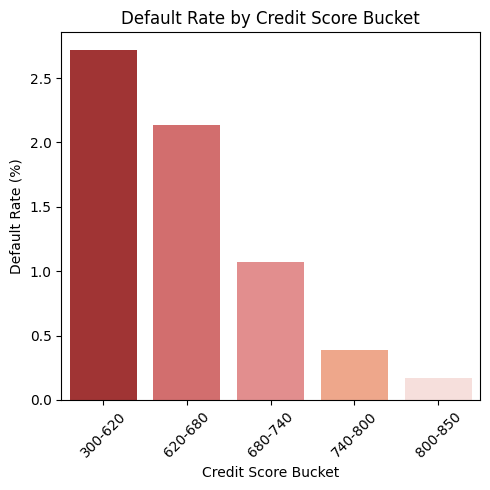

In [ ]:
# Define buckets
cs_bins = [300, 620, 680, 740, 800, 850]
cs_labels = ['300-620', '620-680', '680-740', '740-800', '800-850']
colors = ['#B22222', '#E35D5D', '#F08080', '#FFA07A', '#FADBD8']
mortgage['Credit_Score_Bucket'] = pd.cut(
    mortgage['Credit Score'],
    bins=cs_bins,
    labels=cs_labels,
    include_lowest=True
)

credit_pd = (
    mortgage.groupby('Credit_Score_Bucket')['Default']
    .agg(['mean', 'count'])
    .reset_index()
)

credit_pd.rename(columns={'mean': 'Default_Rate', 'count': 'Loan_Count'}, inplace=True)

# Convert to percentage
credit_pd['Default_Rate'] = credit_pd['Default_Rate'] * 100

print(credit_pd)
plt.figure(figsize=(5, 5))

sns.barplot(
    data=credit_pd,
    x='Credit_Score_Bucket',
    y='Default_Rate',
    palette=colors
)

plt.title('Default Rate by Credit Score Bucket')
plt.xlabel('Credit Score Bucket')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Default Rate by LTV Bucket

In [ ]:
# Create LTV buckets
ltv_bins = [0, 60, 80, 90, 100, 150]
ltv_labels = ['<60%', '60-80%', '80-90%', '90-100%', '>100%']

mortgage['LTV_Bucket'] = pd.cut(
    mortgage['Original Loan-to-Value (LTV)'],
    bins=ltv_bins,
    labels=ltv_labels,
    include_lowest=True
)
ltv_pd = (
    mortgage.groupby('LTV_Bucket')['Default']
    .agg(['mean', 'count'])
    .reset_index()
)
ltv_pd.columns = ['LTV_Bucket', 'Default_Rate', 'Loan_Count']
ltv_pd['Default_Rate'] = ltv_pd['Default_Rate'] * 100
print(ltv_pd)

  LTV_Bucket  Default_Rate  Loan_Count
0       <60%      0.430801     5210757
1     60-80%      0.643734    11550272
2     80-90%      0.884830     2583320
3    90-100%      1.228298     3733703
4      >100%      2.206948      155237


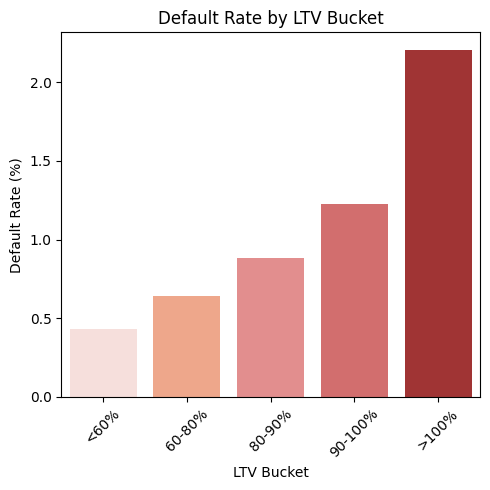

In [ ]:
plt.figure(figsize=(5, 5))
ltv_color = ['#FADBD8', '#FFA07A','#F08080','#E35D5D', '#B22222']
sns.barplot(
    ltv_pd,
    x='LTV_Bucket',
    y='Default_Rate',
    palette=ltv_color
)

plt.title('Default Rate by LTV Bucket')
plt.xlabel('LTV Bucket')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Default Rate by DTI bucket

In [ ]:
dti_bins   = [0, 20, 30, 36, 43, 45, 50, 100]
dti_labels = ['≤20', '21-30', '31-36', '37-43', '44-45', '46-50', '>50']

mortgage['DTI_Bucket'] = pd.cut(
    mortgage['Original Debt-to-Income (DTI) Ratio'],
    bins=dti_bins,
    labels=dti_labels,
    include_lowest=True
)
dti_pd = (
    mortgage.groupby('DTI_Bucket')['Default']
    .agg(['mean', 'count'])
    .reset_index()
)
dti_pd.columns = ['DTI_Bucket', 'Default_Rate', 'Loan_Count']
dti_pd['Default_Rate'] = dti_pd['Default_Rate'] * 100
print(dti_pd)

  DTI_Bucket  Default_Rate  Loan_Count
0        ≤20      0.193801     1997923
1      21-30      0.391573     5216655
2      31-36      0.627364     4296073
3      37-43      0.906530     5954354
4      44-45      1.319985     2009568
5      46-50      0.862057     2534054
6        >50      0.000000         761


#### Default rate by States

In [ ]:
import plotly.express as px

In [ ]:
# Compute default rate by state
state_pd = (
    mortgage.groupby('Property State')['Default']
    .agg(['mean', 'count','sum'])
    .reset_index()
)

state_pd.rename(columns={'mean': 'Default_Rate', 'count': 'Loan_Count','sum':'Default_Count'}, inplace=True)

print(state_pd)
# Optional: filter out very small states to avoid noisy rates
#state_pd = state_pd[state_pd['Loan_Count'] > 100]  # adjust threshold if needed

   Property State  Default_Rate  Loan_Count  Default_Count
0              AK      0.004476       43785            196
1              AL      0.007679      254472           1954
2              AR      0.006339      163761           1038
3              AZ      0.005512      654403           3607
4              CA      0.007657     2740079          20980
5              CO      0.005803      633281           3675
6              CT      0.009224      252052           2325
7              DC      0.014173       52284            741
8              DE      0.005961       88071            525
9              FL      0.010385     1595647          16570
10             GA      0.007625      735606           5609
11             GU      0.023720        4511            107
12             HI      0.012446       74401            926
13             IA      0.005643      201302           1136
14             ID      0.004587      152377            699
15             IL      0.008566     1062921           91

In [ ]:
import plotly.express as px

fig = px.choropleth(
    state_pd,
    locations='Property State',
    locationmode='USA-states',
    color='Default_Rate',
    scope='usa',
    hover_data=['Loan_Count'],
    title='State-Level Default Rate',
    color_continuous_scale='Plasma',   # or keep your current
    range_color=[0.005, 0.02]
)
# Centering the title and adding a border
fig.update_layout(
    title={
        'y': 0.9,           # Sets vertical position
        'x': 0.5,           # Sets horizontal position to the center
        'xanchor': 'center',
        'yanchor': 'top'
    },
    # Adding an outline around the entire chart area
    paper_bgcolor='white',  # Ensures the background is solid
    margin=dict(l=20, r=20, t=60, b=20), # Adds a little padding
    shapes=[
        dict(
            type="rect",
            xref="paper",
            yref="paper",
            x0=0,
            y0=0,
            x1=1,
            y1=1,
            line=dict(color="black", width=2),
        )
    ]
)

fig.show()

## EDA on Loan Level

In [ ]:
agg_dict = {
    'Credit Score':     ('Credit Score',                           'first'),
    'LTV':              ('Original Loan-to-Value (LTV)',            'first'),
    'CLTV':             ('Original Combined Loan-to-Value (CLTV)', 'first'),
    'DTI':              ('Original Debt-to-Income (DTI) Ratio',    'first'),
    'Original_Rate':    ('Original Interest Rate',                 'first'),
    'Original_UPB':     ('Original UPB',                           'first'),
    'Original_Term':    ('Original Loan Term',                     'first'),
    'Num_Borrowers':    ('Number of Borrowers',                    'first'),
    'Occupancy':        ('Occupancy Status',                       'first'),
    'Loan_Purpose':     ('Loan Purpose',                           'first'),
    'Property_Type':    ('Property Type',                          'first'),
    'Property_State':   ('Property State',                         'first'),
    'First_Time_Buyer': ('First Time Homebuyer Flag',              'first'),
    #'zip3':             ('zip3',                                   'first'),
    #'year':             ('year',                                   'first'),
    'ELTV':             ('Estimated Loan-to-Value (ELTV)',         'last'),   # most recent
    'Loan_Age':         ('Loan Age',                               'last'),   # most recent
    'Current_Rate':     ('Current Interest Rate',                  'last'),   # most recent
    'Default':          ('Default',                                'max'),    # ever defaulted
}

loan_level = mortgage.groupby('Loan_ID').agg(**agg_dict).reset_index()

print(f'Loan level shape : {loan_level.shape}')
print(f'Default rate     : {loan_level["Default"].mean():.4f}')
print(f'Total defaults   : {loan_level["Default"].sum():,}')


Loan level shape : (550000, 18)
Default rate     : 0.0336
Total defaults   : 18,455


In [ ]:
loan_level.columns

Index(['Loan_ID', 'Credit Score', 'LTV', 'CLTV', 'DTI', 'Original_Rate',
       'Original_UPB', 'Original_Term', 'Num_Borrowers', 'Occupancy',
       'Loan_Purpose', 'Property_Type', 'Property_State', 'First_Time_Buyer',
       'ELTV', 'Loan_Age', 'Current_Rate', 'Default'],
      dtype='object')

In [ ]:
pd.set_option('display.max_rows', None)
loan_level.isnull().sum()

,0
Loan_ID,0
Credit Score,119
LTV,25
CLTV,38
DTI,16241
Original_Rate,0
Original_UPB,0
Original_Term,0
Num_Borrowers,0
Occupancy,0


### Default rate by credit score bucket

  Credit_Score_Bucket  Default_Rate  Loan_Count  Default_Count
0             300-620     13.623726        2158            294
1             620-680      9.269300       46476           4308
2             680-740      4.896765      160024           7836
3             740-800      1.945820      278443           5418
4             800-850      0.949347       62780            596


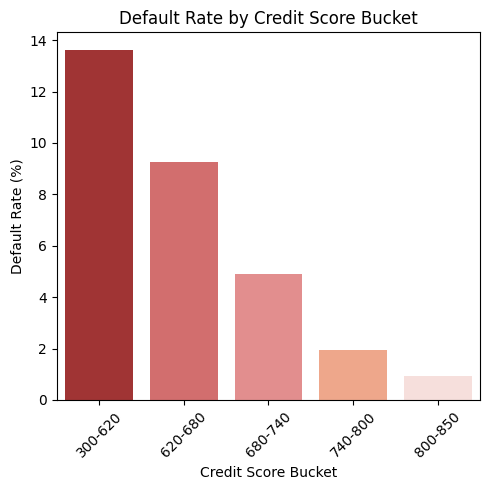

In [ ]:
# Define buckets
cs_bins = [300, 620, 680, 740, 800, 850]
cs_labels = ['300-620', '620-680', '680-740', '740-800', '800-850']
colors = ['#B22222', '#E35D5D', '#F08080', '#FFA07A', '#FADBD8']
loan_level['Credit_Score_Bucket'] = pd.cut(
    loan_level['Credit Score'],
    bins=cs_bins,
    labels=cs_labels,
    include_lowest=True
)

credit_pd = (
    loan_level.groupby('Credit_Score_Bucket')['Default']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
)

credit_pd.rename(columns={'mean': 'Default_Rate', 'count': 'Loan_Count','sum':'Default_Count'}, inplace=True)

# Convert to percentage
credit_pd['Default_Rate'] = credit_pd['Default_Rate'] * 100

print(credit_pd)
plt.figure(figsize=(5, 5))

sns.barplot(
    data=credit_pd,
    x='Credit_Score_Bucket',
    y='Default_Rate',
    palette=colors
)

plt.title('Default Rate by Credit Score Bucket')
plt.xlabel('Credit Score Bucket')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Default Rate by LTV buckets

In [ ]:
# Create LTV buckets
ltv_bins = [0, 60, 80, 90, 100, 150]
ltv_labels = ['<60%', '60-80%', '80-90%', '90-100%', '>100%']

loan_level['LTV_Bucket'] = pd.cut(
    loan_level['LTV'],
    bins=ltv_bins,
    labels=ltv_labels,
    include_lowest=True
)
ltv_pd = (
    loan_level.groupby('LTV_Bucket')['Default']
    .agg(['mean', 'count','sum'])
    .reset_index()
)
ltv_pd.columns = ['LTV_Bucket', 'Default_Rate', 'Loan_Count','Default_Count']
ltv_pd['Default_Rate'] = ltv_pd['Default_Rate'] * 100
print(ltv_pd)

  LTV_Bucket  Default_Rate  Loan_Count  Default_Count
0       <60%      2.276191      118751           2703
1     60-80%      3.148704      267888           8435
2     80-90%      3.789058       64264           2435
3    90-100%      4.738833       97007           4597
4      >100%     13.194805        1925            254


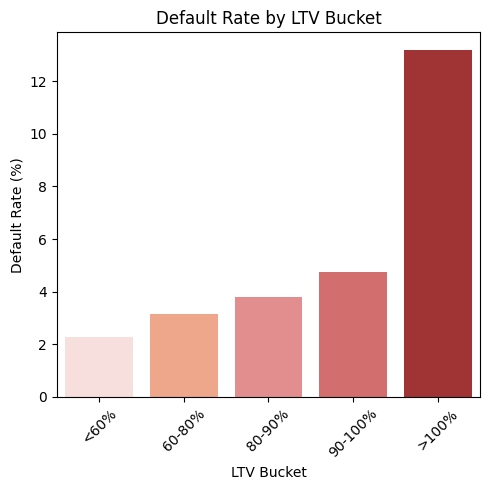

In [ ]:
plt.figure(figsize=(5, 5))
ltv_color = ['#FADBD8', '#FFA07A','#F08080','#E35D5D', '#B22222']
sns.barplot(
    ltv_pd,
    x='LTV_Bucket',
    y='Default_Rate',
    palette=ltv_color
)

plt.title('Default Rate by LTV Bucket')
plt.xlabel('LTV Bucket')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Default rate by DTI bucket

In [ ]:
dti_bins   = [0, 20, 30, 36, 43, 45, 50, 100]
dti_labels = ['≤20', '21-30', '31-36', '37-43', '44-45', '46-50', '>50']

loan_level['DTI_Bucket'] = pd.cut(
    loan_level['DTI'],
    bins=dti_bins,
    labels=dti_labels,
    include_lowest=True
)
dti_pd = (
    loan_level.groupby('DTI_Bucket')['Default']
    .agg(['mean', 'count','sum'])
    .reset_index()
)
dti_pd.columns = ['DTI_Bucket', 'Default_Rate', 'Loan_Count', 'Default_Count']
dti_pd['Default_Rate'] = dti_pd['Default_Rate'] * 100
print(dti_pd)

  DTI_Bucket  Default_Rate  Loan_Count  Default_Count
0        ≤20      1.167829       43157            504
1      21-30      1.972217      118851           2344
2      31-36      2.902261      102334           2970
3      37-43      3.992821      144860           5784
4      44-45      5.635504       49685           2800
5      46-50      3.580494       74850           2680
6        >50      0.000000          22              0


### Default rate by States

In [ ]:
# Compute default rate by state
state_pd = (
    loan_level.groupby('Property_State')['Default']
    .agg(['mean', 'count','sum'])
    .reset_index()
)

state_pd.rename(columns={'mean': 'Default_Rate', 'count': 'Loan_Count','sum':'Default_Count'}, inplace=True)

state_pd = state_pd[state_pd['Loan_Count']>100]
state_pd = state_pd[state_pd['Property_State']!='PR']

print(state_pd)
# Optional: filter out very small states to avoid noisy rates
#state_pd = state_pd[state_pd['Loan_Count'] > 100]  # adjust threshold if needed

   Property_State  Default_Rate  Loan_Count  Default_Count
0              AK      0.024731         930             23
1              AL      0.031311        6100            191
2              AR      0.032692        3793            124
3              AZ      0.026313       17444            459
4              CA      0.035143       65732           2310
5              CO      0.024346       16635            405
6              CT      0.045165        5491            248
7              DC      0.043956        1183             52
8              DE      0.027501        2109             58
9              FL      0.050435       38089           1921
10             GA      0.036231       17609            638
12             HI      0.050641        1560             79
13             IA      0.024920        4695            117
14             ID      0.025886        3979            103
15             IL      0.035012       24563            860
16             IN      0.024528       13128            3

In [ ]:
import plotly.express as px

fig = px.choropleth(
    state_pd,
    locations='Property_State',
    locationmode='USA-states',
    color='Default_Rate',
    scope='usa',
    hover_data=['Loan_Count'],
    title='State-Level Default Rate',
    color_continuous_scale='Plasma',   # or keep your current
    #range_color=[0.005, 0.02]
)
# Centering the title and adding a border
fig.update_layout(
    title={
        'y': 0.9,           # Sets vertical position
        'x': 0.5,           # Sets horizontal position to the center
        'xanchor': 'center',
        'yanchor': 'top'
    },
    # Adding an outline around the entire chart area
    paper_bgcolor='white',  # Ensures the background is solid
    margin=dict(l=20, r=20, t=60, b=20), # Adds a little padding
    shapes=[
        dict(
            type="rect",
            xref="paper",
            yref="paper",
            x0=0,
            y0=0,
            x1=1,
            y1=1,
            line=dict(color="black", width=2),
        )
    ]
)

fig.show()

### Baseline Modeling

In [ ]:
EXCLUDE = [
    'Loan_ID', 'Default',                    # target / ID
    'Current Loan Delinquency Status', 'Delinquency_Numeric', # leakage
    'Monthly Reporting Period', 'year',                        # time index
    'Current Actual UPB', 'Current Interest Rate',            # time-varying
    'Current Deferred UPB', 'Interest Bearing UPB',           # time-varying
    'Loan Age', 'Remaining Months to Legal Maturity',         # time-varying
    'Modification Flag', 'Zero Balance Code',                  # post-event
    'Zero Balance Effective Date', 'Current Month Modification Cost',
    'Delinquency Due to Disaster',
    'Due Date of Last Paid Installment (DDLPI)',
    'Postal Code',                                             # use zip3 instead
    'Defect Settlement Date',                                  # >99% null
    'Seller Name', 'Servicer Name',                           # high-cardinality
    'First Payment Date', 'Maturity Date',                    # date fields (use term)
    'Metropolitan Statistical Area (MSA) Or Metropolitan Division',# 11% null, high-card
    'Credit_Score_Bucket', 'LTV_Bucket', 'DTI_Bucket',
    'ELTV','CLTV'
]

FEATURES = [c for c in loan_level.columns if c not in EXCLUDE]
print(FEATURES)



['Credit Score', 'LTV', 'DTI', 'Original_Rate', 'Original_UPB', 'Original_Term', 'Num_Borrowers', 'Occupancy', 'Loan_Purpose', 'Property_Type', 'Property_State', 'First_Time_Buyer', 'Loan_Age', 'Current_Rate']


In [ ]:
df_model = loan_level[FEATURES + ['Default']].copy()

In [ ]:
df_model.shape

(550000, 15)

In [ ]:
df_model.columns

Index(['Credit Score', 'LTV', 'DTI', 'Original_Rate', 'Original_UPB',
       'Original_Term', 'Num_Borrowers', 'Occupancy', 'Loan_Purpose',
       'Property_Type', 'Property_State', 'First_Time_Buyer', 'Loan_Age',
       'Current_Rate', 'Default'],
      dtype='object')

In [ ]:
pd.set_option('display.max_rows', None)
df_model.isnull().sum()

,0
Credit Score,119
LTV,25
DTI,16241
Original_Rate,0
Original_UPB,0
Original_Term,0
Num_Borrowers,0
Occupancy,0
Loan_Purpose,0
Property_Type,0


In [ ]:
df_model = df_model.dropna(subset=['Credit Score', 'LTV'])

In [ ]:
dti_median = df_model['DTI'].median()
df_model['DTI'] = df_model['DTI'].fillna(dti_median)

In [ ]:
pd.set_option('display.max_rows', None)
df_model.isnull().sum()

,0
Credit Score,0
LTV,0
DTI,0
Original_Rate,0
Original_UPB,0
Original_Term,0
Num_Borrowers,0
Occupancy,0
Loan_Purpose,0
Property_Type,0


In [ ]:
df_model['Rate_Spread'] = df_model['Current_Rate'] - df_model['Original_Rate']

In [ ]:
df_model = df_model.drop(columns=['Original_Rate'])

In [ ]:
print(df_model.columns.tolist())
print(df_model.shape)

['Credit Score', 'LTV', 'DTI', 'Original_UPB', 'Original_Term', 'Num_Borrowers', 'Occupancy', 'Loan_Purpose', 'Property_Type', 'Property_State', 'First_Time_Buyer', 'Loan_Age', 'Current_Rate', 'Default', 'Rate_Spread']
(549856, 15)


In [ ]:
print(f"Shape after cleaning : {df_model.shape}")
print(f"Remaining nulls      : {df_model.isnull().sum().sum()}")
print(f"Default rate         : {df_model['Default'].mean():.4f}")

Shape after cleaning : (549856, 15)
Remaining nulls      : 0
Default rate         : 0.0335


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 549856 entries, 0 to 549999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Credit Score      549856 non-null  float64
 1   LTV               549856 non-null  float64
 2   DTI               549856 non-null  float64
 3   Original_UPB      549856 non-null  int64  
 4   Original_Term     549856 non-null  int64  
 5   Num_Borrowers     549856 non-null  int64  
 6   Occupancy         549856 non-null  object 
 7   Loan_Purpose      549856 non-null  object 
 8   Property_Type     549856 non-null  object 
 9   Property_State    549856 non-null  object 
 10  First_Time_Buyer  549856 non-null  object 
 11  Loan_Age          549856 non-null  int64  
 12  Current_Rate      549856 non-null  float64
 13  Default           549856 non-null  int64  
 14  Rate_Spread       549856 non-null  float64
dtypes: float64(5), int64(5), object(5)
memory usage: 67.1+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix)
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

In [ ]:
#Encode categoricals
cat_cols = ['Occupancy', 'Loan_Purpose', 'Property_Type', 'Property_State', 'First_Time_Buyer']
for col in cat_cols:
    df_model[col] = df_model[col].astype('category').cat.codes

print("Encoding done.")
print(df_model[cat_cols].head(3))

Encoding done.
   Occupancy  Loan_Purpose  Property_Type  Property_State  First_Time_Buyer
0          0             1              4              30                 1
1          1             1              3              46                 1
2          1             1              4              13                 1


In [ ]:
#Define X and y
FEATURE_COLS = [c for c in df_model.columns if c != 'Default']
X = df_model[FEATURE_COLS]
y = df_model['Default']

In [ ]:
print(f"\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Default rate         : {df_model['Default'].mean():.4f}")


Features (14): ['Credit Score', 'LTV', 'DTI', 'Original_UPB', 'Original_Term', 'Num_Borrowers', 'Occupancy', 'Loan_Purpose', 'Property_Type', 'Property_State', 'First_Time_Buyer', 'Loan_Age', 'Current_Rate', 'Rate_Spread']
Class distribution:
Default
0    531409
1     18447
Name: count, dtype: int64
Default rate         : 0.0335


### Modeling

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves 3.35% default rate in both splits
)

print(f"\nTrain : {X_train.shape} | Default rate: {y_train.mean():.4f}")
print(f"Test  : {X_test.shape}  | Default rate: {y_test.mean():.4f}")


Train : (439884, 14) | Default rate: 0.0335
Test  : (109972, 14)  | Default rate: 0.0335


In [ ]:
#Scale features ────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [ ]:
# Logistic Regression ───────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    penalty='l2',
    C=0.1,                    # strong regularization — many features
    class_weight='balanced',  # handles 3.35% minority class
    solver='saga',            # best for large datasets
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

In [ ]:
lr.fit(X_train_sc, y_train)
print("\nLogistic Regression trained.")


Logistic Regression trained.


In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix)
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

def evaluate_model(model, X_sc, y_true, label='Set'):
    y_prob = model.predict_proba(X_sc)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    print(f"\n{'═'*45}")
    print(f"  {label}")
    print(f"{'═'*45}")
    print(f"  AUROC : {auroc:.4f}")
    print(f"  AUPRC : {auprc:.4f}  (random baseline = {y_true.mean():.4f})")
    print(f"\n{classification_report(y_true, y_pred, zero_division=0)}")
    return y_prob

In [ ]:
y_prob_train = evaluate_model(lr, X_train_sc, y_train, 'TRAIN')
y_prob_test  = evaluate_model(lr, X_test_sc,  y_test,  'TEST')


═════════════════════════════════════════════
  TRAIN
═════════════════════════════════════════════
  AUROC : 0.7925
  AUPRC : 0.1833  (random baseline = 0.0335)

              precision    recall  f1-score   support

           0       0.99      0.72      0.83    425126
           1       0.08      0.72      0.15     14758

    accuracy                           0.72    439884
   macro avg       0.53      0.72      0.49    439884
weighted avg       0.96      0.72      0.81    439884


═════════════════════════════════════════════
  TEST
═════════════════════════════════════════════
  AUROC : 0.7947
  AUPRC : 0.1816  (random baseline = 0.0335)

              precision    recall  f1-score   support

           0       0.99      0.72      0.83    106283
           1       0.08      0.73      0.15      3689

    accuracy                           0.72    109972
   macro avg       0.53      0.72      0.49    109972
weighted avg       0.96      0.72      0.81    109972



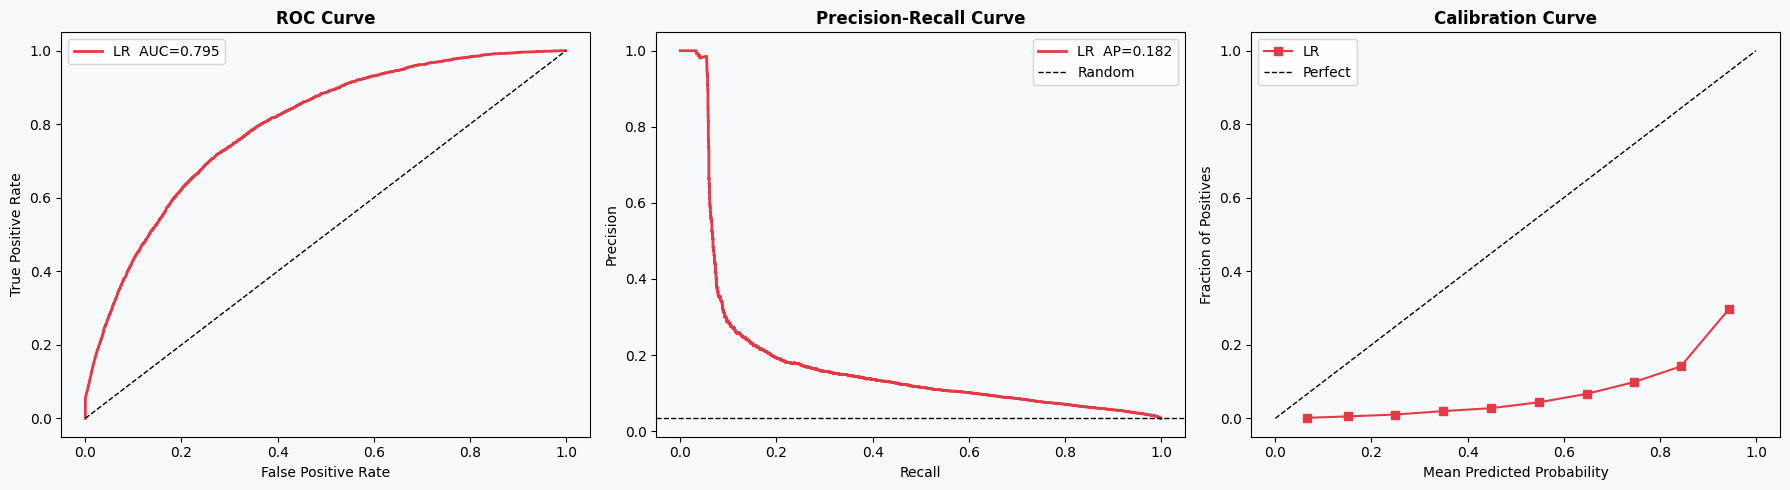

In [ ]:
# ── Step 7: Diagnostic plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0].plot(fpr, tpr, lw=2, color='#E63946',
             label=f'LR  AUC={roc_auc_score(y_test, y_prob_test):.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision-Recall curve
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_test)
axes[1].plot(rec_c, prec_c, lw=2, color='#E63946',
             label=f'LR  AP={average_precision_score(y_test, y_prob_test):.3f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)
axes[2].plot(prob_pred, prob_true, 's-', color='#E63946', label='LR')
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Perfect')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve', fontweight='bold')
axes[2].legend()

for ax in axes:
    ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig('pd_model_diagnostics.png', dpi=150)
plt.show()

In [ ]:
# ── Step 8: Coefficient inspection ───────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Coefficient': lr.coef_[0],
    'Odds_Ratio' : np.exp(lr.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("\nTop 10 risk-INCREASING features:")
print(coef_df.head(10).to_string(index=False))
print("\nTop 10 risk-DECREASING features:")
print(coef_df.tail(10).to_string(index=False))


Top 10 risk-INCREASING features:
         Feature  Coefficient  Odds_Ratio
        Loan_Age     0.559400    1.749622
             DTI     0.356280    1.428007
             LTV     0.325137    1.384220
   Original_Term     0.172407    1.188161
    Original_UPB     0.028228    1.028630
First_Time_Buyer     0.020343    1.020551
   Property_Type     0.018496    1.018668
  Property_State    -0.054790    0.946684
       Occupancy    -0.061746    0.940122
    Loan_Purpose    -0.142029    0.867596

Top 10 risk-DECREASING features:
         Feature  Coefficient  Odds_Ratio
    Original_UPB     0.028228    1.028630
First_Time_Buyer     0.020343    1.020551
   Property_Type     0.018496    1.018668
  Property_State    -0.054790    0.946684
       Occupancy    -0.061746    0.940122
    Loan_Purpose    -0.142029    0.867596
    Current_Rate    -0.142697    0.867017
   Num_Borrowers    -0.346389    0.707237
    Credit Score    -0.718948    0.487265
     Rate_Spread    -1.124018    0.324971


Random Forest

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, roc_curve,
                              precision_recall_curve)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale_pos:.2f}")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scale_pos_weight : 28.81


#### Random Forest - Hypertuning and Estimation

In [ ]:
# ── 1a. Hyperparameter Tuning ─────────────────────────────────────────────────
print("\n" + "="*55)
print("  RANDOM FOREST — Hyperparameter Tuning")
print("="*55)

rf_param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [4, 6, 8, 10, None],
    'min_samples_leaf': [20, 50, 100, 200],
    'max_features':     ['sqrt', 'log2', 0.5],
    'class_weight':     ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='average_precision',  # AUPRC — right metric for imbalanced data
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"\nBest RF Parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k:25s} : {v}")
print(f"\nBest CV AUPRC : {rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_


  RANDOM FOREST — Hyperparameter Tuning
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF Parameters:
  n_estimators              : 200
  min_samples_leaf          : 20
  max_features              : 0.5
  max_depth                 : None
  class_weight              : balanced_subsample

Best CV AUPRC : 0.2006


In [ ]:
# ── 1b. Evaluate ──────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  RANDOM FOREST — Model Evaluation")
print("="*55)

y_prob_train_rf = evaluate_model(rf_best, X_train, y_train, 'RF — TRAIN')
y_prob_test_rf  = evaluate_model(rf_best, X_test,  y_test,  'RF — TEST')


  RANDOM FOREST — Model Evaluation

═════════════════════════════════════════════
  RF — TRAIN
═════════════════════════════════════════════
  AUROC : 0.9790
  AUPRC : 0.5970  (random baseline = 0.0335)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    425126
           1       0.36      0.91      0.52     14758

    accuracy                           0.94    439884
   macro avg       0.68      0.93      0.74    439884
weighted avg       0.98      0.94      0.96    439884


═════════════════════════════════════════════
  RF — TEST
═════════════════════════════════════════════
  AUROC : 0.8072
  AUPRC : 0.2057  (random baseline = 0.0335)

              precision    recall  f1-score   support

           0       0.98      0.94      0.96    106283
           1       0.17      0.37      0.23      3689

    accuracy                           0.92    109972
   macro avg       0.57      0.65      0.59    109972
weighted avg       0.95     

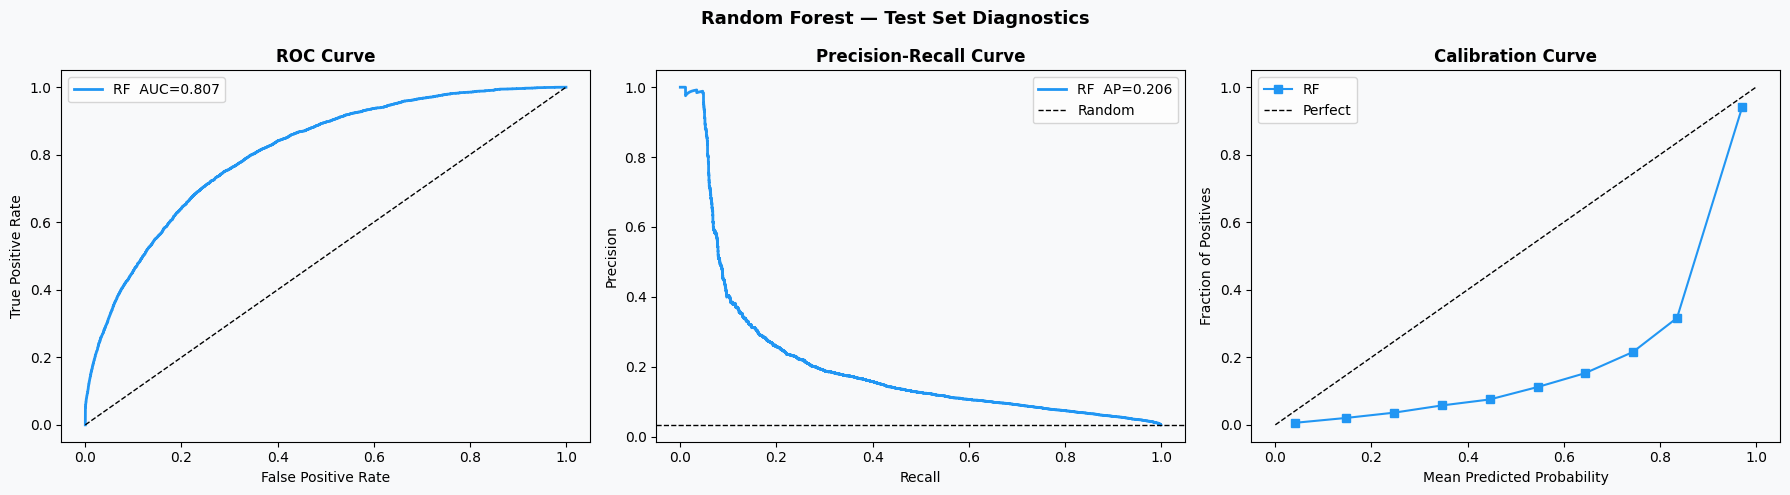

In [ ]:
# ── 1c. Individual Diagnostic Plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_test_rf)
axes[0].plot(fpr_rf, tpr_rf, lw=2, color='#2196F3',
             label=f'RF  AUC={roc_auc_score(y_test, y_prob_test_rf):.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_test_rf)
axes[1].plot(rec_rf, prec_rf, lw=2, color='#2196F3',
             label=f'RF  AP={average_precision_score(y_test, y_prob_test_rf):.3f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_test_rf, n_bins=10)
axes[2].plot(prob_pred_rf, prob_true_rf, 's-', color='#2196F3', label='RF')
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Perfect')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve', fontweight='bold')
axes[2].legend()

for ax in axes:
    ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Random Forest — Test Set Diagnostics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('rf_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


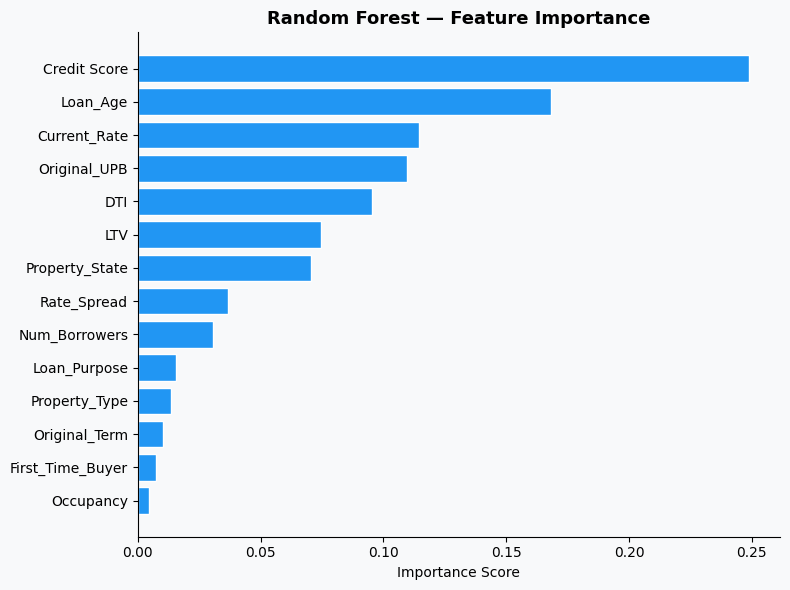

In [ ]:
# ── 1d. RF Feature Importance ─────────────────────────────────────────────────
rf_feat_imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(rf_feat_imp['Feature'], rf_feat_imp['Importance'],
        color='#2196F3', edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

In [ ]:
# ── 1e. Tuning Results — CV scores across iterations ─────────────────────────
rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results = rf_cv_results.sort_values('rank_test_score')

print("\nTop 10 RF parameter combinations:")
print(rf_cv_results[['params', 'mean_test_score', 'std_test_score']]
      .head(10).to_string(index=False))



Top 10 RF parameter combinations:
                                                                                                                        params  mean_test_score  std_test_score
   {'n_estimators': 200, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced_subsample'}         0.200621        0.009537
{'n_estimators': 200, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced_subsample'}         0.190909        0.008715
     {'n_estimators': 500, 'min_samples_leaf': 50, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced_subsample'}         0.189080        0.008408
               {'n_estimators': 100, 'min_samples_leaf': 50, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced'}         0.187855        0.008770
      {'n_estimators': 500, 'min_samples_leaf': 50, 'max_features': 0.5, 'max_depth': 8, 'class_weight': 'balanced_subsample'}         0.186786        0.008556
     

### XG Boost - Hypertuning and Estimation

In [ ]:
# ── 2a. Hyperparameter Tuning ─────────────────────────────────────────────────
print("\n" + "="*55)
print("  XGBOOST — Hyperparameter Tuning")
print("="*55)

xgb_param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 5, 10, 20],
    'gamma':            [0, 0.1, 0.5, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=42
    ),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"\nBest XGB Parameters:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k:25s} : {v}")
print(f"\nBest CV AUPRC : {xgb_search.best_score_:.4f}")

xgb_best = xgb_search.best_estimator_


  XGBOOST — Hyperparameter Tuning
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB Parameters:
  subsample                 : 0.8
  n_estimators              : 500
  min_child_weight          : 5
  max_depth                 : 6
  learning_rate             : 0.05
  gamma                     : 1.0
  colsample_bytree          : 0.8

Best CV AUPRC : 0.2155


In [ ]:
# ── 2b. Evaluate ──────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  XGBOOST — Model Evaluation")
print("="*55)

y_prob_train_xgb = evaluate_model(xgb_best, X_train, y_train, 'XGB — TRAIN')
y_prob_test_xgb  = evaluate_model(xgb_best, X_test,  y_test,  'XGB — TEST')


  XGBOOST — Model Evaluation

═════════════════════════════════════════════
  XGB — TRAIN
═════════════════════════════════════════════
  AUROC : 0.8761
  AUPRC : 0.2725  (random baseline = 0.0335)

              precision    recall  f1-score   support

           0       0.99      0.75      0.86    425126
           1       0.10      0.83      0.19     14758

    accuracy                           0.76    439884
   macro avg       0.55      0.79      0.52    439884
weighted avg       0.96      0.76      0.83    439884


═════════════════════════════════════════════
  XGB — TEST
═════════════════════════════════════════════
  AUROC : 0.8181
  AUPRC : 0.2217  (random baseline = 0.0335)

              precision    recall  f1-score   support

           0       0.99      0.75      0.85    106283
           1       0.09      0.73      0.16      3689

    accuracy                           0.75    109972
   macro avg       0.54      0.74      0.51    109972
weighted avg       0.96      0.7

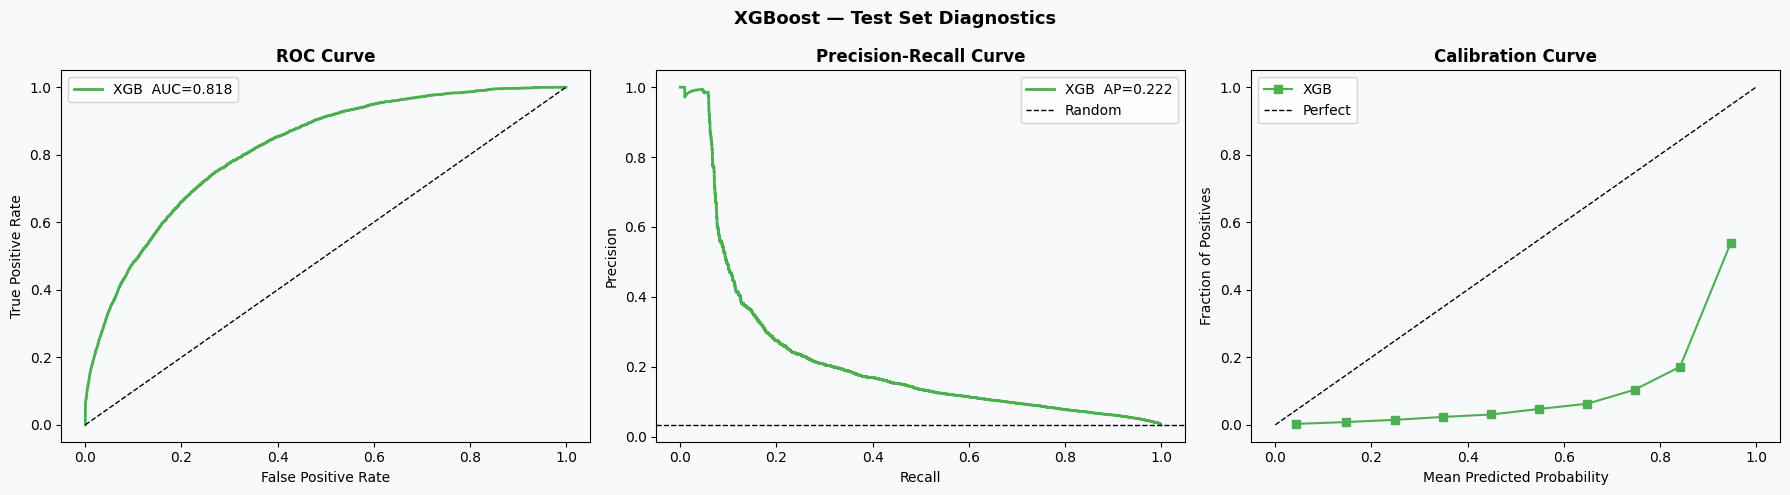

In [ ]:
# ── 2c. Individual Diagnostic Plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_test_xgb)
axes[0].plot(fpr_xgb, tpr_xgb, lw=2, color='#4CAF50',
             label=f'XGB  AUC={roc_auc_score(y_test, y_prob_test_xgb):.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_test_xgb)
axes[1].plot(rec_xgb, prec_xgb, lw=2, color='#4CAF50',
             label=f'XGB  AP={average_precision_score(y_test, y_prob_test_xgb):.3f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_prob_test_xgb, n_bins=10)
axes[2].plot(prob_pred_xgb, prob_true_xgb, 's-', color='#4CAF50', label='XGB')
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Perfect')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve', fontweight='bold')
axes[2].legend()

for ax in axes:
    ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('XGBoost — Test Set Diagnostics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('xgb_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

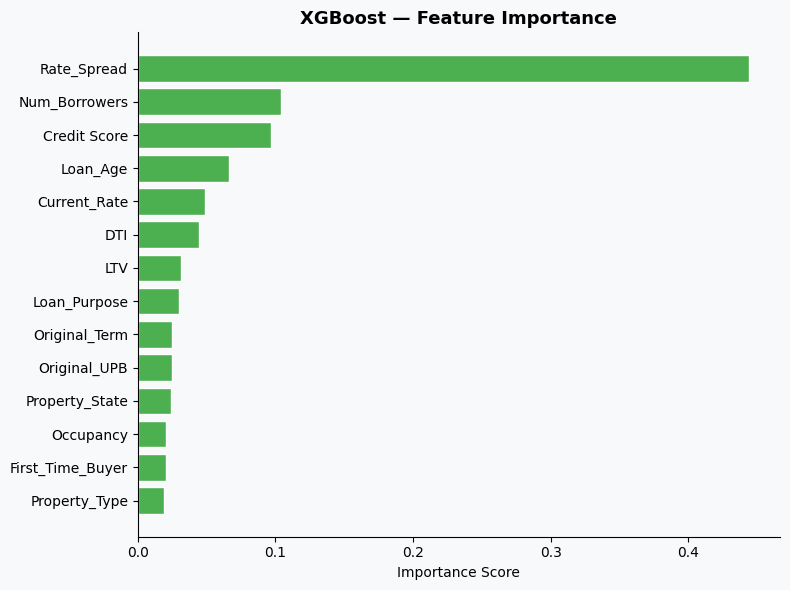

In [ ]:
# ── 2d. XGBoost Feature Importance ───────────────────────────────────────────
xgb_feat_imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(xgb_feat_imp['Feature'], xgb_feat_imp['Importance'],
        color='#4CAF50', edgecolor='white')
ax.set_title('XGBoost — Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()


In [ ]:
# ── 2e. Tuning Results — CV scores across iterations ─────────────────────────
xgb_cv_results = pd.DataFrame(xgb_search.cv_results_)
xgb_cv_results = xgb_cv_results.sort_values('rank_test_score')

print("\nTop 10 XGB parameter combinations:")
print(xgb_cv_results[['params', 'mean_test_score', 'std_test_score']]
      .head(10).to_string(index=False))


Top 10 XGB parameter combinations:
                                                                                                                                      params  mean_test_score  std_test_score
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.8}         0.215451        0.009376
 {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.8}         0.215277        0.009574
  {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}         0.215258        0.009093
 {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 1.0, 'colsample_bytree': 0.6}         0.214754        0.009692
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate

### COMBINED COMPARISON — All 3 Models

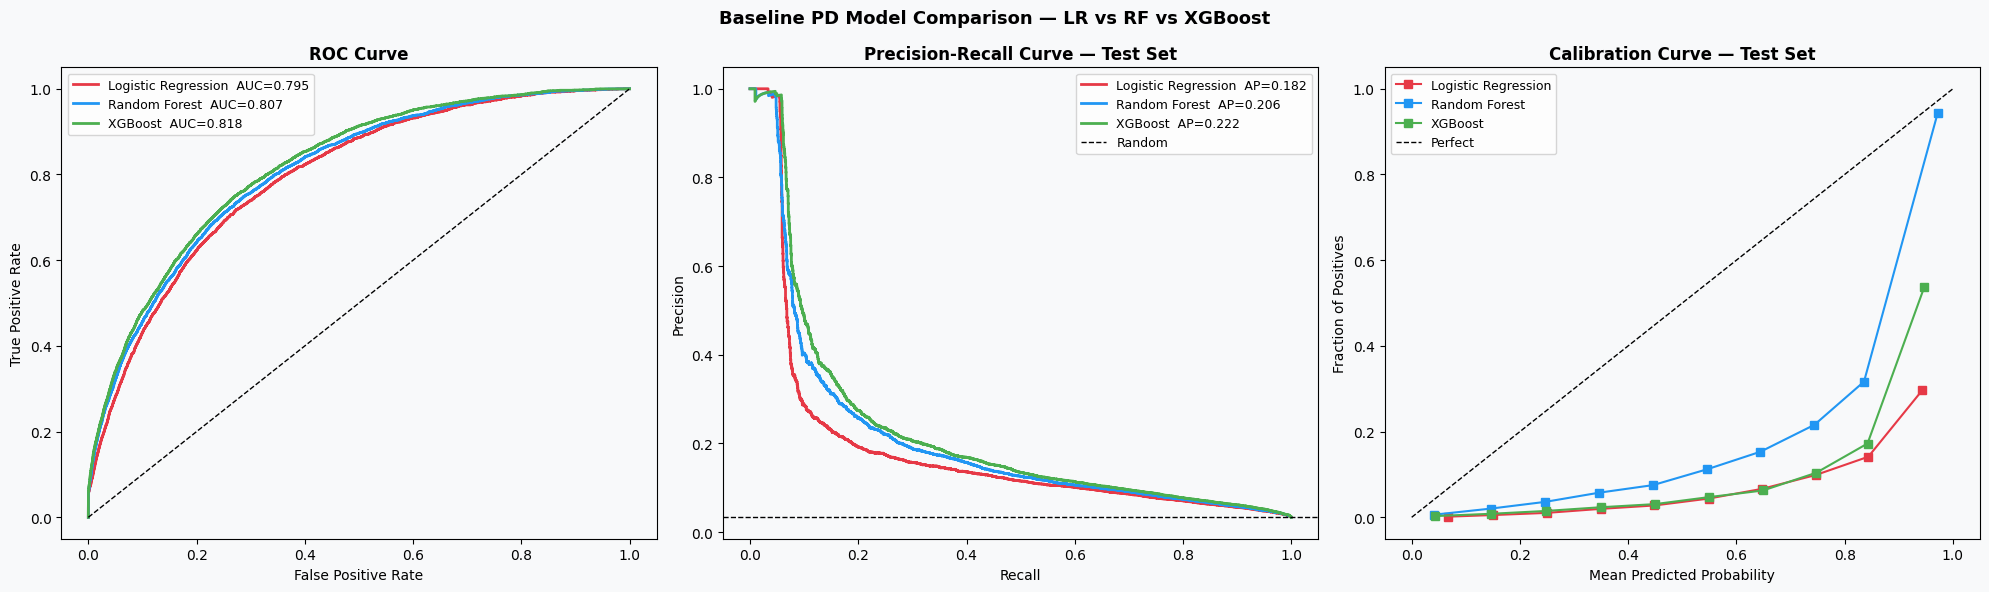

In [ ]:
# Combined Diagnostic Plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

MODELS = {
    'Logistic Regression': (y_prob_test,     '#E63946'),
    'Random Forest':        (y_prob_test_rf,  '#2196F3'),
    'XGBoost':              (y_prob_test_xgb, '#4CAF50'),
}

for name, (y_prob, color) in MODELS.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auroc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)

for name, (y_prob, color) in MODELS.items():
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    axes[1].plot(rec_c, prec_c, lw=2, color=color, label=f'{name}  AP={auprc:.3f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Test Set', fontweight='bold')
axes[1].legend(fontsize=9)

for name, (y_prob, color) in MODELS.items():
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    axes[2].plot(prob_pred, prob_true, 's-', color=color, label=name)
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Perfect')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve — Test Set', fontweight='bold')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Baseline PD Model Comparison — LR vs RF vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pd_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 3b. Final Summary Table ───────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUROC': [
        roc_auc_score(y_test, y_prob_test),
        roc_auc_score(y_test, y_prob_test_rf),
        roc_auc_score(y_test, y_prob_test_xgb)
    ],
    'AUPRC': [
        average_precision_score(y_test, y_prob_test),
        average_precision_score(y_test, y_prob_test_rf),
        average_precision_score(y_test, y_prob_test_xgb)
    ],
    'Lift_over_Random': [
        average_precision_score(y_test, y_prob_test)     / y_test.mean(),
        average_precision_score(y_test, y_prob_test_rf)  / y_test.mean(),
        average_precision_score(y_test, y_prob_test_xgb) / y_test.mean()
    ]
}).round(4)

print("\n" + "="*60)
print("  BASELINE PD MODEL — FINAL COMPARISON")
print("="*60)
print(summary.to_string(index=False))
print(f"\n  Random baseline AUPRC : {y_test.mean():.4f}")
print(f"  Best params RF        : {rf_search.best_params_}")
print(f"  Best params XGB       : {xgb_search.best_params_}")


  BASELINE PD MODEL — FINAL COMPARISON
              Model  AUROC  AUPRC  Lift_over_Random
Logistic Regression 0.7947 0.1816            5.4130
      Random Forest 0.8072 0.2057            6.1335
            XGBoost 0.8181 0.2217            6.6077

  Random baseline AUPRC : 0.0335
  Best params RF        : {'n_estimators': 200, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced_subsample'}
  Best params XGB       : {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.8}


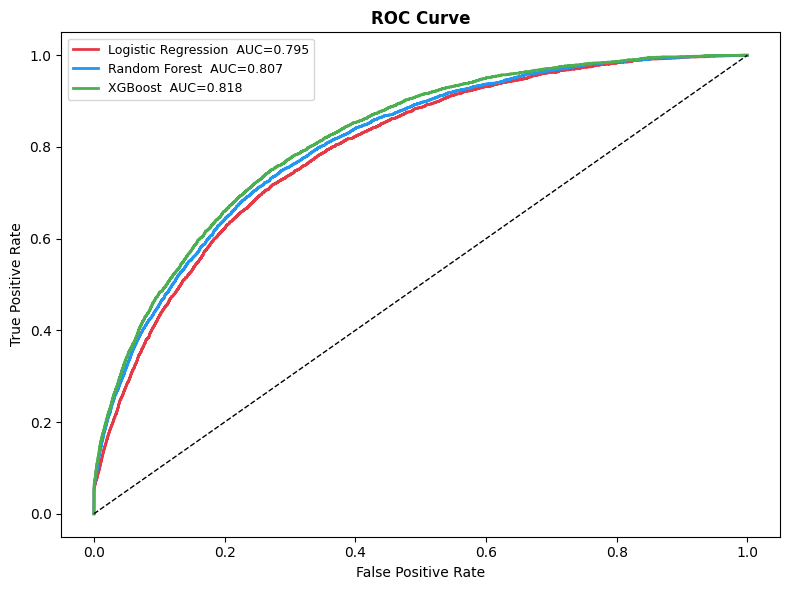

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

MODELS = {
    'Logistic Regression': (y_prob_test,     '#E63946'),
    'Random Forest':        (y_prob_test_rf,  '#2196F3'),
    'XGBoost':              (y_prob_test_xgb, '#4CAF50'),
}

for name, (y_prob, color) in MODELS.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    axes.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auroc:.3f}')
axes.plot([0,1],[0,1],'k--', lw=1)
axes.set_xlabel('False Positive Rate')
axes.set_ylabel('True Positive Rate')
axes.set_title('ROC Curve', fontweight='bold')
axes.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pd_model_combined_ROC.png', dpi=150, bbox_inches='tight')
plt.show()